# Globally (80S - 80N) integrated pteropod

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pyseaflux

In [8]:
# Calcul de l’aire par maille (lat × lon)
lon = np.arange(-180, 180)
lat = np.arange(-80, 81)
area = pyseaflux.area.area_grid(lat, lon, return_dataarray=True)  # DataArray(lat, lon)
area = area.rename({"lon": "longitude", "lat": "latitude"})
area = area.chunk({"latitude": 10,"longitude": 10})
# Ouverture couche épipélagique
ds_pld = xr.open_zarr("/data/rd_exchange/sroyer/SEAPOPYM/Sophie_GLOBAL_MULTIYEAR_BGC_001_033.zarr")
ds_pld=ds_pld.chunk({ "time": -1, "latitude": 10,"longitude": 10})
ds_pld = ds_pld.sel(
    time=slice('1999-01-01','2022-12-31'),
    latitude=slice(-80,80),
    depth=0  # épipélagique
).drop_vars("depth",errors='ignore')

# Masquage terre / mer
da_pld = ds_pld['pelagic_layer_depth']
da_pld = da_pld.where(ds_pld['mask'])

# Calcul du volume (area [m2] * depth [m])
volume = area * da_pld  # (time, lat, lon)


def integrate_biomass(da_biomass,volume):
    # Calcul de l'intégrale biomasse × volume
    #  (fg, time, lat, lon) * (time, lat, lon)
    biomass_volume = da_biomass * volume  # (fg, time, lat, lon)

    # Somme spatiale (fg, time)
    integrated = biomass_volume.sum(dim=['latitude', 'longitude'], skipna=True)

    return integrated

In [19]:
volume = volume.transpose("time", "latitude", "longitude")

In [26]:
volume['time'] = volume['time'].dt.floor('D')

## No Transport

In [4]:
# load dataset
path="/data/rd_exchange/sroyer/SEAPOPYM/outputs/global_no_transport_1998_2022.zarr"

ds_no_transport=xr.open_zarr(path)
ds_no_transport = ds_no_transport.rename({'__xarray_dataarray_variable__': 'biomass'})
# select good time, lat
ds_no_transport = ds_no_transport.sel(
    time=slice('1999-01-01', '2022-12-31'), 
    latitude=slice(-80, 80)
    )
da_no_t = ds_no_transport['biomass']  # shape (functional_group, time, lat, lon)


In [32]:
da_no_t

<xarray.DataArray 'biomass' (time: 8766, latitude: 161, longitude: 360)> Size: 2GB
dask.array<getitem, shape=(8766, 161, 360), dtype=float32, chunksize=(8766, 10, 10), chunktype=numpy.ndarray>
Coordinates:
    depth             int16 2B ...
  * longitude         (longitude) int16 720B -180 -179 -178 -177 ... 177 178 179
    functional_group  int64 8B ...
  * time              (time) datetime64[ns] 70kB 1999-01-01 ... 2022-12-31
  * latitude          (latitude) int16 322B -80 -79 -78 -77 -76 ... 77 78 79 80
Attributes:
    units:    kilogram / meter**3

In [25]:
print(da_no_t.time)

<xarray.DataArray 'time' (time: 8766)> Size: 70kB
array(['1999-01-01T00:00:00.000000000', '1999-01-02T00:00:00.000000000',
       '1999-01-03T00:00:00.000000000', ..., '2022-12-29T00:00:00.000000000',
       '2022-12-30T00:00:00.000000000', '2022-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    depth             int16 2B ...
    functional_group  int64 8B ...
  * time              (time) datetime64[ns] 70kB 1999-01-01 ... 2022-12-31
Attributes:
    standard_name:  time
    axis:           T


In [27]:
print(volume.time)

<xarray.DataArray 'time' (time: 8766)> Size: 70kB
array(['1999-01-01T00:00:00.000000000', '1999-01-02T00:00:00.000000000',
       '1999-01-03T00:00:00.000000000', ..., '2022-12-29T00:00:00.000000000',
       '2022-12-30T00:00:00.000000000', '2022-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 70kB 1999-01-01 1999-01-02 ... 2022-12-31
Attributes:
    standard_name:  time
    axis:           T


In [28]:
# integrate 
intergrated_no_trans=integrate_biomass(da_no_t,volume)

In [31]:
print(intergrated_no_trans)

<xarray.DataArray (time: 8766)> Size: 70kB
dask.array<sum-aggregate, shape=(8766,), dtype=float64, chunksize=(8766,), chunktype=numpy.ndarray>
Coordinates:
    depth             int16 2B ...
    functional_group  int64 8B ...
  * time              (time) datetime64[ns] 70kB 1999-01-01 ... 2022-12-31


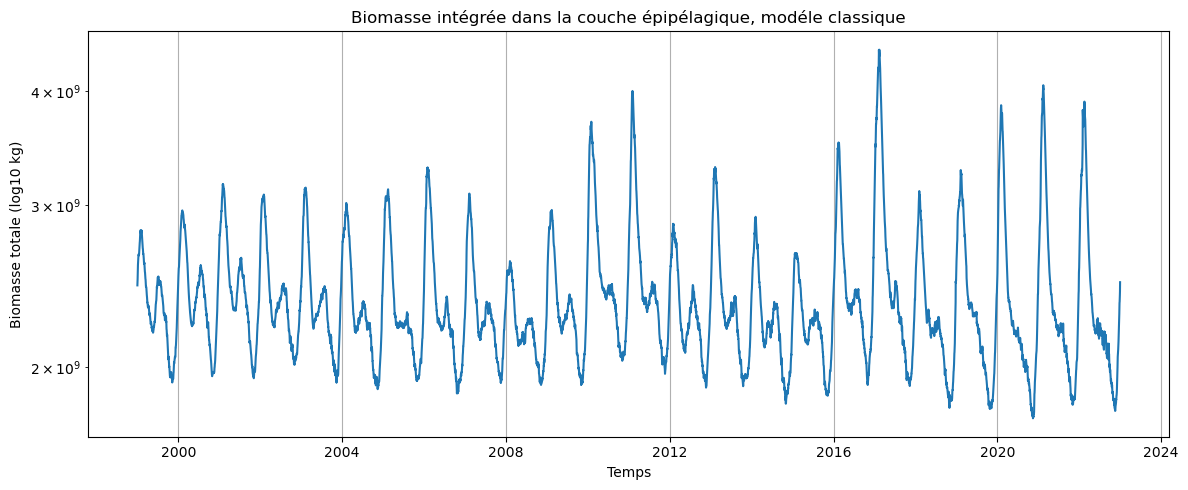

In [34]:
# Charger les données en mémoire si c'est du dask (évite .compute() si énorme)
time = intergrated_no_trans['time'].values
values = intergrated_no_trans.values

# Tracé
plt.figure(figsize=(12, 5))
plt.plot(time, values)
plt.yscale('log')
plt.xlabel('Temps')
plt.ylabel('Biomasse totale (log10 kg)')
plt.title('Biomasse intégrée dans la couche épipélagique, modéle classique')
plt.grid(True)
plt.tight_layout()
plt.show()


## Acidity

In [35]:
# load dataset
path="/data/rd_exchange/sroyer/SEAPOPYM/outputs/global_acidity_ar_1998_2022.zarr"

ds_acidity_ar=xr.open_zarr(path)
ds_acidity_ar = ds_acidity_ar.rename({'__xarray_dataarray_variable__': 'biomass'})
# select good time, lat
ds_acidity_ar = ds_acidity_ar.sel(
    time=slice('1999-01-01', '2022-12-31'), 
    latitude=slice(-80, 80)
    )
da_ac_ar = ds_acidity_ar['biomass'] 

In [36]:
# integrate 
intergrated_ac_ar=integrate_biomass(da_ac_ar,volume)

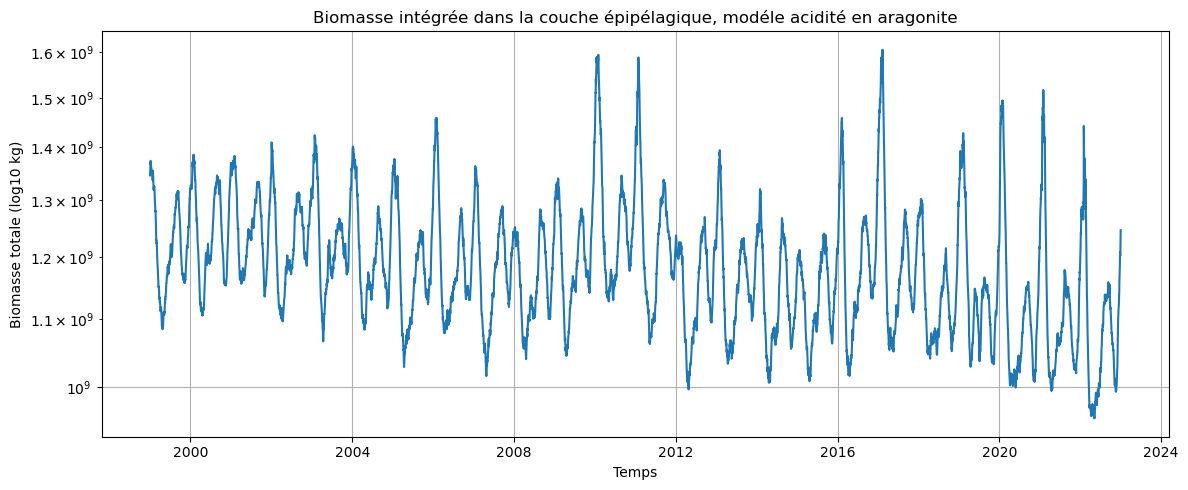

In [38]:
# Charger les données en mémoire si c'est du dask (évite .compute() si énorme)
time = intergrated_ac_ar['time'].values
values = intergrated_ac_ar.values

# Tracé
plt.figure(figsize=(12, 5))
plt.plot(time, values)
plt.yscale('log')
plt.xlabel('Temps')
plt.ylabel('Biomasse totale (log10 kg)')
plt.title('Biomasse intégrée dans la couche épipélagique, modéle acidité en aragonite')
plt.grid(True)
plt.tight_layout()
plt.show()


## No transport param acidity

In [42]:
# load dataset
path="/data/rd_exchange/sroyer/SEAPOPYM/outputs/global_no_transport_arparam_1998_2022.zarr"

ds_no_t_ar=xr.open_zarr(path)
ds_no_t_ar = ds_no_t_ar.rename({'__xarray_dataarray_variable__': 'biomass'})
# select good time, lat
ds_no_t_ar = ds_no_t_ar.sel(
    time=slice('1999-01-01', '2022-12-31'), 
    latitude=slice(-80, 80)
    )
da_no_t_ar = ds_no_t_ar['biomass'] 

In [43]:
# integrate 
intergrated_no_t_ar=integrate_biomass(da_no_t_ar,volume)

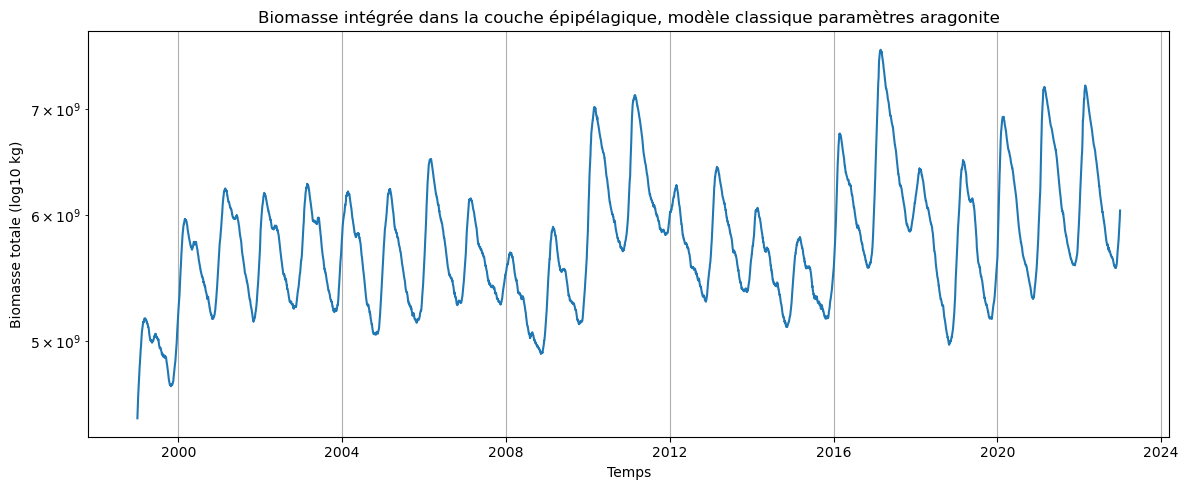

In [45]:
# Charger les données en mémoire si c'est du dask (évite .compute() si énorme)
time = intergrated_no_t_ar['time'].values
values = intergrated_no_t_ar.values

# Tracé
plt.figure(figsize=(12, 5))
plt.plot(time, values)
plt.yscale('log')
plt.xlabel('Temps')
plt.ylabel('Biomasse totale (log10 kg)')
plt.title('Biomasse intégrée dans la couche épipélagique, modèle classique paramètres aragonite')
plt.grid(True)
plt.tight_layout()
plt.show()


## Comparaison

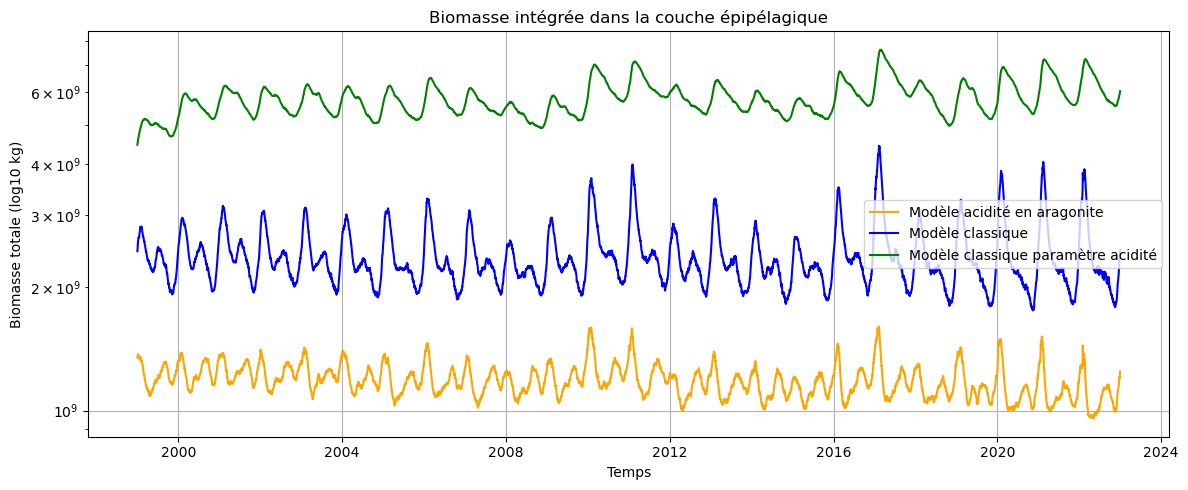

In [46]:
# Charger les données en mémoire si c'est du dask (évite .compute() si énorme)
time = intergrated_ac_ar['time'].values
values_ar = intergrated_ac_ar.values
values_no_t=intergrated_no_trans.values
values_no_t_ar=intergrated_no_t_ar.values
# Tracé
plt.figure(figsize=(12, 5))
plt.plot(time, values_ar,'orange',label="Modèle acidité en aragonite")
plt.plot(time, values_no_t,'blue',label="Modèle classique")
plt.plot(time, values_no_t_ar,'green',label="Modèle classique paramètre acidité")
plt.yscale('log')
plt.xlabel('Temps')
plt.ylabel('Biomasse totale (log10 kg)')
plt.title('Biomasse intégrée dans la couche épipélagique')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


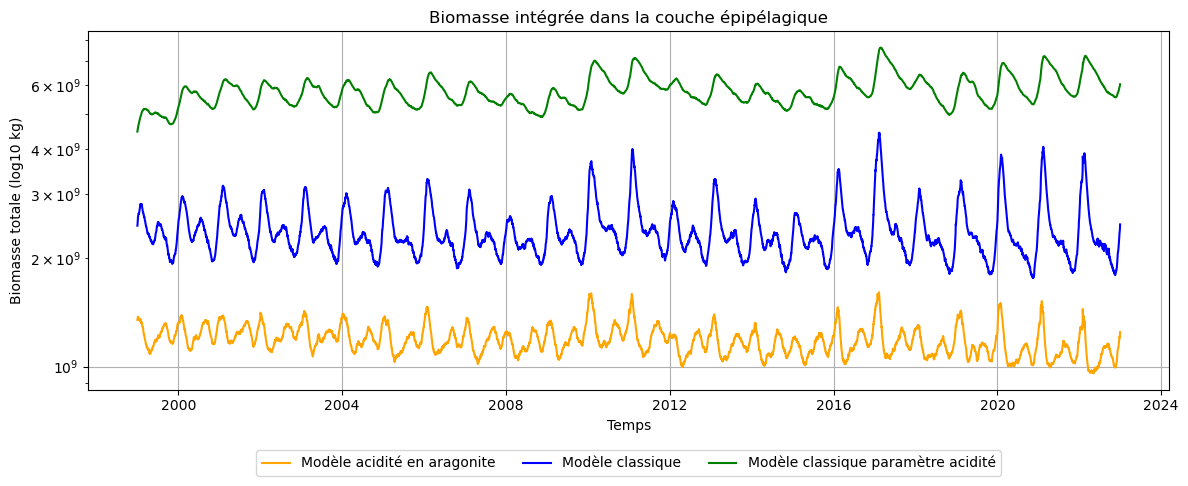

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))

# Tracés
ax.plot(time, values_ar, 'orange', label="Modèle acidité en aragonite")
ax.plot(time, values_no_t, 'blue', label="Modèle classique")
ax.plot(time, values_no_t_ar, 'green', label="Modèle classique paramètre acidité")

# Log scale et autres éléments
ax.set_yscale('log')
ax.set_xlabel('Temps')
ax.set_ylabel('Biomasse totale (log10 kg)')
ax.set_title('Biomasse intégrée dans la couche épipélagique')
ax.grid(True)

# Légende sous le plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()
